In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import UpROOT.io as io
import UpROOT.config as conf
import UpROOT.physics.delphes as ph
import UpROOT.plotting.delphes as pt
import UpROOT.pipelines.delphes as pl
import UpROOT.fitting.delphes as fi
import UpROOT.delphes_root as dr

In [3]:
DATASET01 = 'mpmm_70GeV'

In [4]:
collections = (
    'EFlowTrack',
    'Electron',
    'Event',
    'Jet',
    'Muon',
    'Particle',
    'Photon',
    'ScalarHT',
    'Track',
    'Weight'
)

In [6]:
io.load_dataframe(
    branches=io.txt_data("mpmm"),
    dataset=DATASET01,
).head()

Ramas cargadas desde: C:\Users\mario\Documents\PF\MadGraph\analysis\mpmm.txt
Cantidad de ramas: 33
Archivo: MG5_pp_mpmm_100k_70GeV_01.root
Árbol seleccionado: Delphes
Archivo: MG5_pp_mpmm_100k_70GeV_02.root
Árbol seleccionado: Delphes
Archivo: MG5_pp_mpmm_100k_70GeV_03.root
Árbol seleccionado: Delphes
Total de eventos: 300,000 eventos


,Event/Event.CrossSection,Event/Event.CrossSectionError,Event/Event.Number,Event/Event.Weight,Jet/Jet.BTag,Jet/Jet.Charge,Jet/Jet.ChargedEnergyFraction,Jet/Jet.Constituents,Jet/Jet.Eta,Jet/Jet.Mass,...,Muon/Muon.IsolationVarRhoCorr,Muon/Muon.PT,Muon/Muon.Particle,Muon/Muon.Phi,Muon/Muon.SumPt,Muon/Muon.SumPtCharged,Muon/Muon.SumPtChargedPU,Muon/Muon.SumPtNeutral,Muon/Muon.T,Muon_size
0,[2.366332769393921],[59158.3203125],[0],[0.04310808330774307],[],[],[],[],[],[],...,"[0.0, 0.0]","[1.4442028999328613, 1.1412245035171509]","[{'ref': 80}, {'ref': 79}]","[0.28182050585746765, -2.909900188446045]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[1.0882267531542311e-08, 1.0405063477492149e-08]",2
1,[4.732665538787842],[0.0],[1],[31726.65234375],[],[],[],[],[],[],...,[0.0],[1.769708275794983],[{'ref': 29}],[2.8597030639648438],[0.0],[0.0],[0.0],[0.0],[1.0290602148188555e-08],1
2,[7.098998546600342],[0.0],[2],[31941.45703125],[],[],[],[],[],[],...,"[0.0, 0.0]","[1.6018954515457153, 1.1485521793365479]","[{'ref': 16}, {'ref': 15}]","[0.6304005980491638, -2.1212830543518066]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[1.0205273959229544e-08, 6.948178032928354e-09]",2
3,[9.465331077575684],[0.0],[3],[42941.40625],[],[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],0
4,[11.831664085388184],[0.00028760748682543635],[4],[31682.23828125],[],[],[],[],[],[],...,"[0.0, 0.0]","[2.8276143074035645, 1.8647631406784058]","[{'ref': 41}, {'ref': 40}]","[2.5612406730651855, 0.3249083161354065]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[1.066668176008534e-08, 6.830921606137963e-09]",2


In [10]:
output = dr.convert_dataset(
    dataset=DATASET01,
    collections=collections,
    step_size='20 MB',
    object_registry=True,
    overwrite=True,
    create_dimuons=False
)

Ramas internas de ROOT excluidas:
 - EFlowNeutralHadron/EFlowNeutralHadron.fBits
 - EFlowPhoton/EFlowPhoton.fBits
 - EFlowTrack/EFlowTrack.fBits
 - Electron/Electron.fBits
 - Event/Event.fBits
 - FatJet/FatJet.fBits
 - GenJet/GenJet.fBits
 - GenMissingET/GenMissingET.fBits
 - Jet/Jet.fBits
 - MissingET/MissingET.fBits
 - Muon/Muon.fBits
 - Particle/Particle.fBits
 - Photon/Photon.fBits
 - ScalarHT/ScalarHT.fBits
 - Tower/Tower.fBits
 - Track/Track.fBits
 - Weight/Weight.fBits

Archivo de entrada: C:\Users\mario\Documents\PF\data\MG5_pp_mpmm_100k_70GeV_01.root
Eventos: 100,000
Colecciones: EFlowTrack, Electron, Jet, Muon, Particle, Photon, ScalarHT, Track, Weight
 EFlowTracks: 54 ramas; bloques de 20 MB
 Electrons: 18 ramas; bloques de 20 MB
 Jets: 46 ramas; bloques de 20 MB
 Muons: 17 ramas; bloques de 20 MB
 Particles: 23 ramas; bloques de 20 MB
 Photons: 15 ramas; bloques de 20 MB
 ScalarHT: 2 ramas; bloques de 20 MB
 Tracks: 54 ramas; bloques de 20 MB
 Weights: 2 ramas; bloques de 2

In [5]:
PDATASET01 = 'mpmm_70GeV_p'

In [6]:
cut = '(Eta < 5.0) & (Eta > 2)'

In [25]:
df_events = io.load_dataframe(
    branches=None,
    dataset=PDATASET01,
    tree_path='Events',
)
df_events.head()

Archivo: mpmm_70GeV_pandas.root
Árbol seleccionado: Events
Total de eventos: 300,000 eventos


,source_file_id,event_id,source_entry,root_uid,event_number,ReadTime,ProcTime,ProcessID,MPI,event_weight,...,PDF2,n_EFlowTrack,n_Electron,n_Jet,n_Muon,n_Particle,n_Photon,n_ScalarHT,n_Track,n_Weight
0,0,0,0,0,0,0.174753,0.001585,9999,-1,0.043108,...,0.0,5,0,0,2,286,0,1,5,292
1,0,1,1,0,1,0.004387,0.000668,9999,-1,31726.652344,...,0.0,6,0,0,1,173,0,1,6,292
2,0,2,2,0,2,0.000338,0.000269,9999,-1,31941.457031,...,0.0,4,0,0,2,90,0,1,4,292
3,0,3,3,0,3,0.000715,0.001471,9999,-1,42941.406250,...,0.0,4,0,0,0,267,0,1,4,292
4,0,4,4,0,4,0.000595,0.000744,9999,-1,31682.238281,...,0.0,3,0,0,2,209,0,1,3,292


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\event_multiplicities_70GeV_01.png.


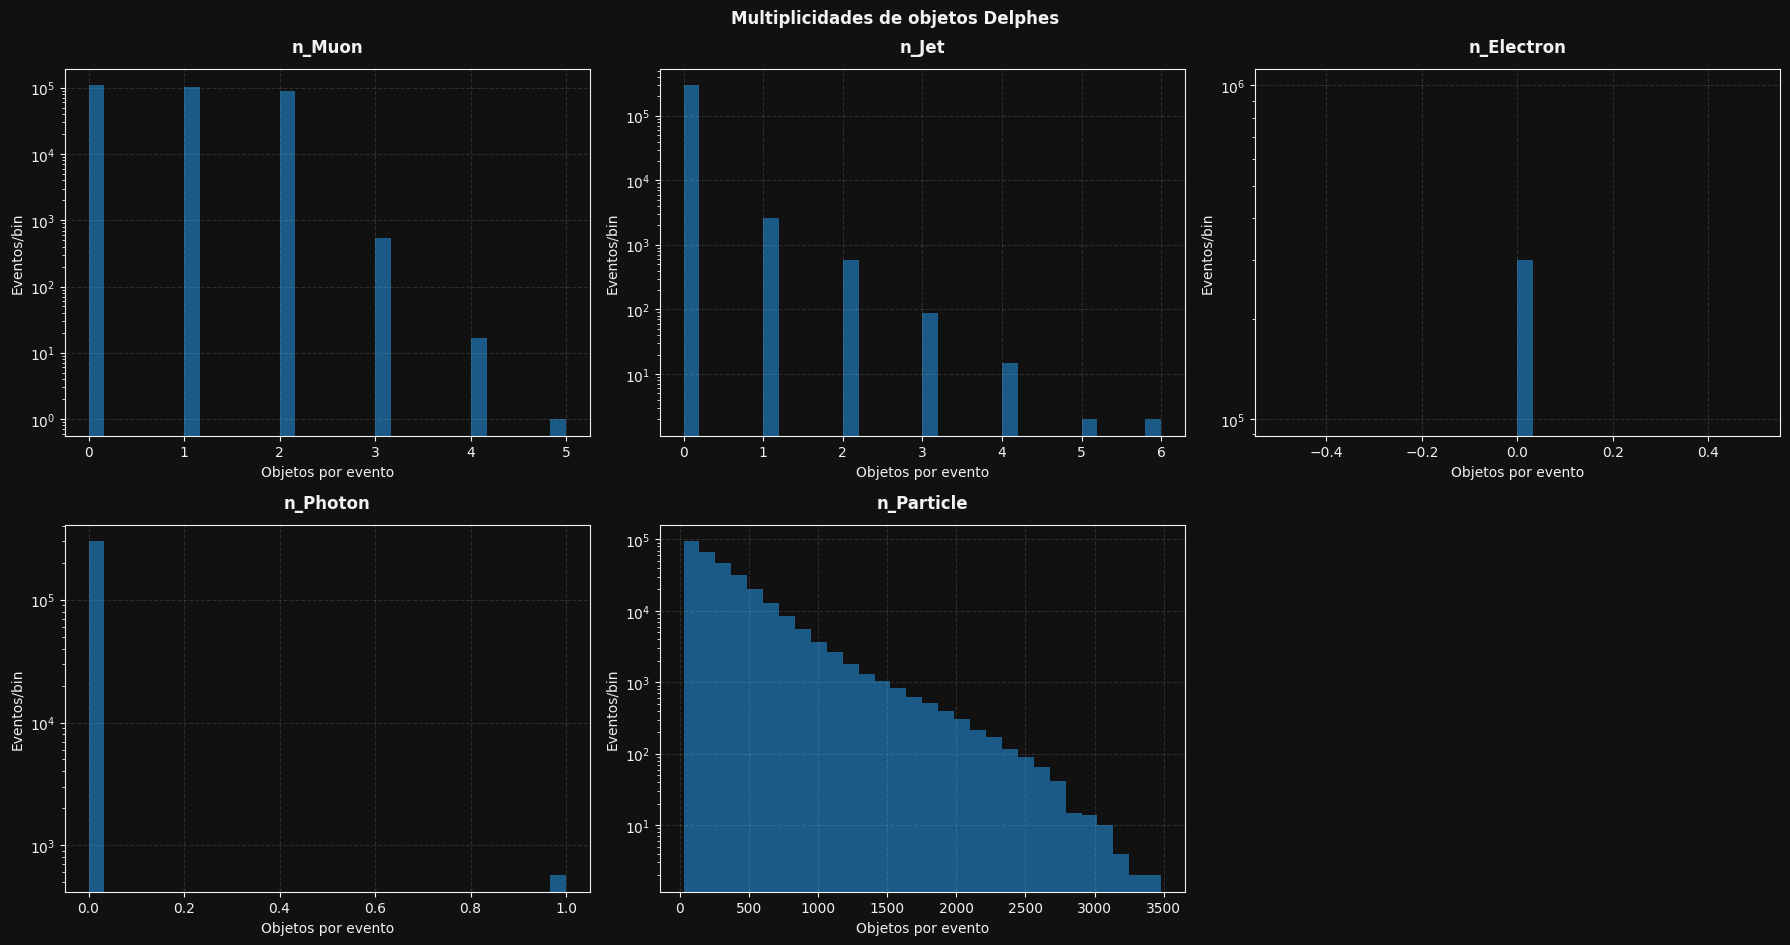

(<Figure size 1800x960 with 6 Axes>,
 array([[<Axes: title={'center': 'n_Muon'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Jet'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Electron'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>],
        [<Axes: title={'center': 'n_Photon'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Particle'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: >]], dtype=object))

In [8]:
pt.plot_event_multiplicities(
    df_events, 
    data='delphes02', 
    save=True, 
    filename='event_multiplicities_70GeV_01'
)

In [26]:
df_muons = io.load_dataframe(
    branches=None,
    dataset=PDATASET01,
    tree_path='Muons'
)
df_muons.head(7)

Archivo: mpmm_70GeV_pandas.root
Árbol seleccionado: Muons
Total de eventos: 281,201 eventos


,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,IsolationVar,IsolationVarRhoCorr,SumPtCharged,SumPtNeutral,SumPtChargedPU,SumPt,D0,DZ,ErrorD0,ErrorDZ
0,0,0,0,0,393,1.444203,1.588587,0.281821,1.088227e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0
1,0,0,0,1,392,1.141225,1.972527,-2.909900,1.040506e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0
2,0,1,1,0,264,1.769708,2.136832,2.859703,1.029060e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0
3,0,2,2,0,144,1.601895,-2.314334,0.630401,1.020527e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,6.544414e-14,-7.470573e-13,0.0,0.0
4,0,2,2,1,143,1.148552,-0.938239,-2.121283,6.948178e-09,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0
5,0,4,4,0,317,2.827614,-1.723009,2.561241,1.066668e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0
6,0,4,4,1,316,1.864763,-0.999608,0.324908,6.830922e-09,1,...,0.0,0.0,0.0,0.0,0.0,0.0,-3.322348e-14,-7.547673e-13,0.0,0.0


In [27]:
cdf_muons = io.load_dataframe(
    branches=None,
    dataset=PDATASET01,
    tree_path='Muons',
    cut=cut
)
cdf_muons.head(7)

Archivo: mpmm_70GeV_pandas.root
Árbol seleccionado: Muons
Total de eventos: 26,592 eventos


,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,IsolationVar,IsolationVarRhoCorr,SumPtCharged,SumPtNeutral,SumPtChargedPU,SumPt,D0,DZ,ErrorD0,ErrorDZ
2,0,1,1,0,264,1.769708,2.136832,2.859703,1.029060e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48,0,45,45,0,183,1.171718,2.065295,0.226416,1.033631e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
67,0,61,61,0,248,1.195463,2.144423,0.385404,1.028757e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
78,0,73,73,0,157,2.901314,2.194488,2.786878,1.025881e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
82,0,78,78,0,173,2.909660,2.041533,1.327660,1.035050e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
101,0,102,102,0,470,3.985861,2.458504,-0.799699,1.015464e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
117,0,112,112,0,399,1.014019,2.474409,0.120156,1.015138e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\muon_kinematics_70GeV_01.png.


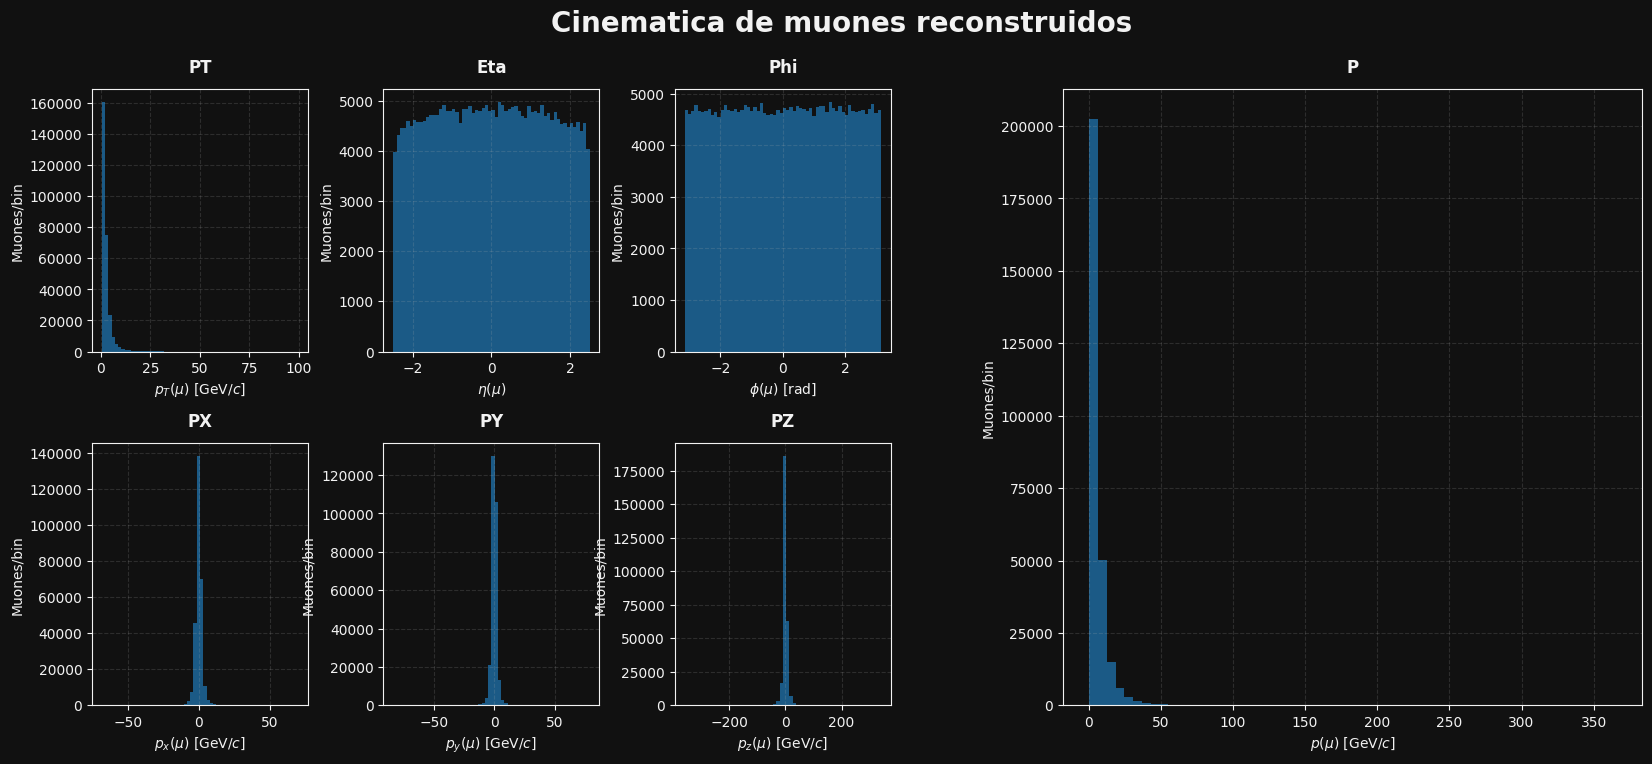

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [11]:
pt.plot_muon_kinematics(
    df_muons, 
    bins=60, 
    data='delphes02', 
    save=True, 
    filename="muon_kinematics_70GeV_01"
)

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\muon_kinematics_70GeV_01_cut.png.


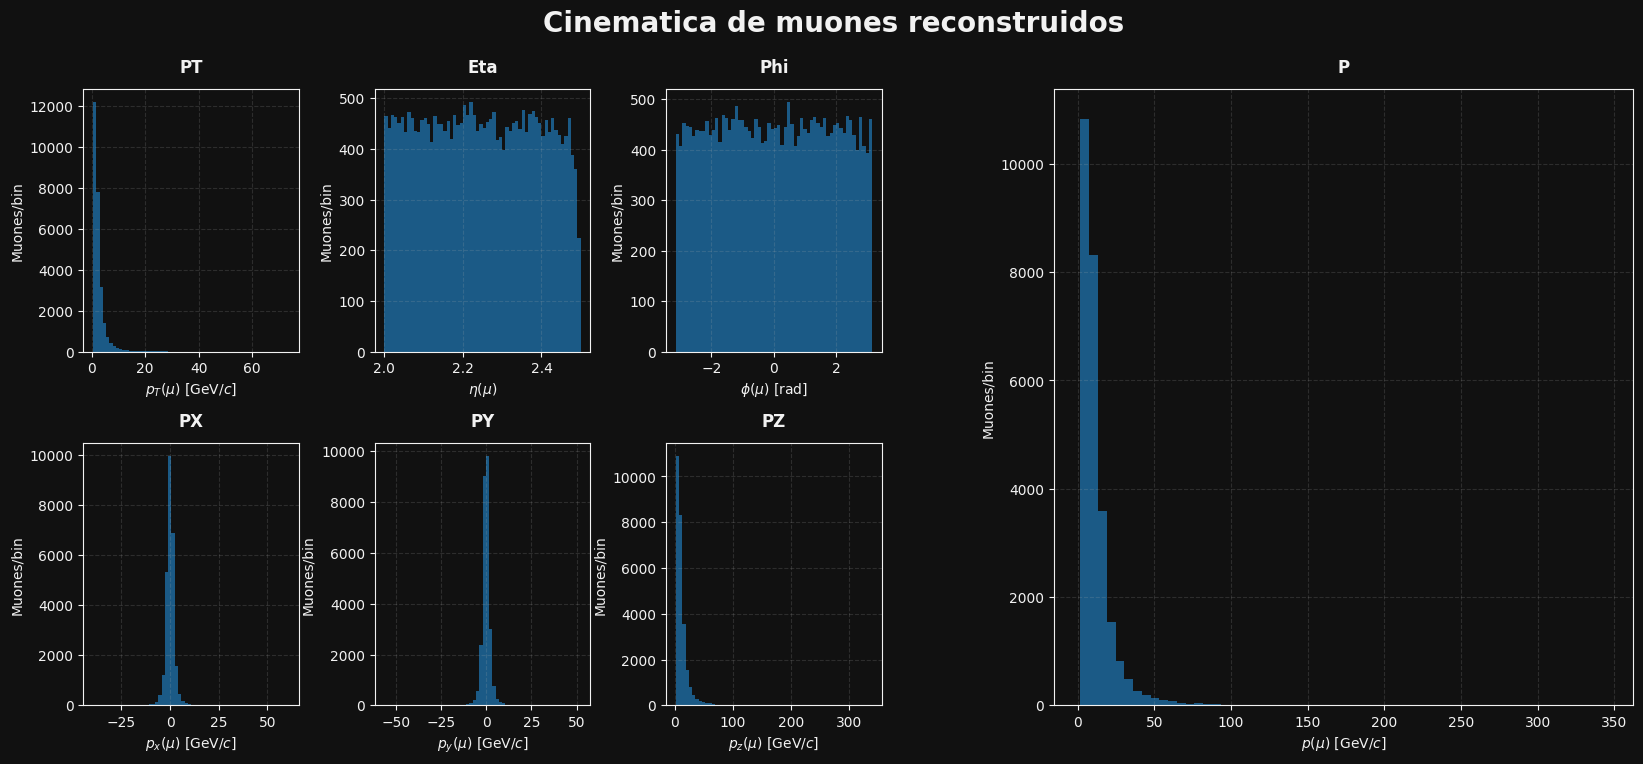

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [12]:
pt.plot_muon_kinematics(
    cdf_muons, 
    bins=60, 
    data='delphes02', 
    save=True, 
    filename="muon_kinematics_70GeV_01_cut"
)

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\muon_kinematics_70GeV_02.png.


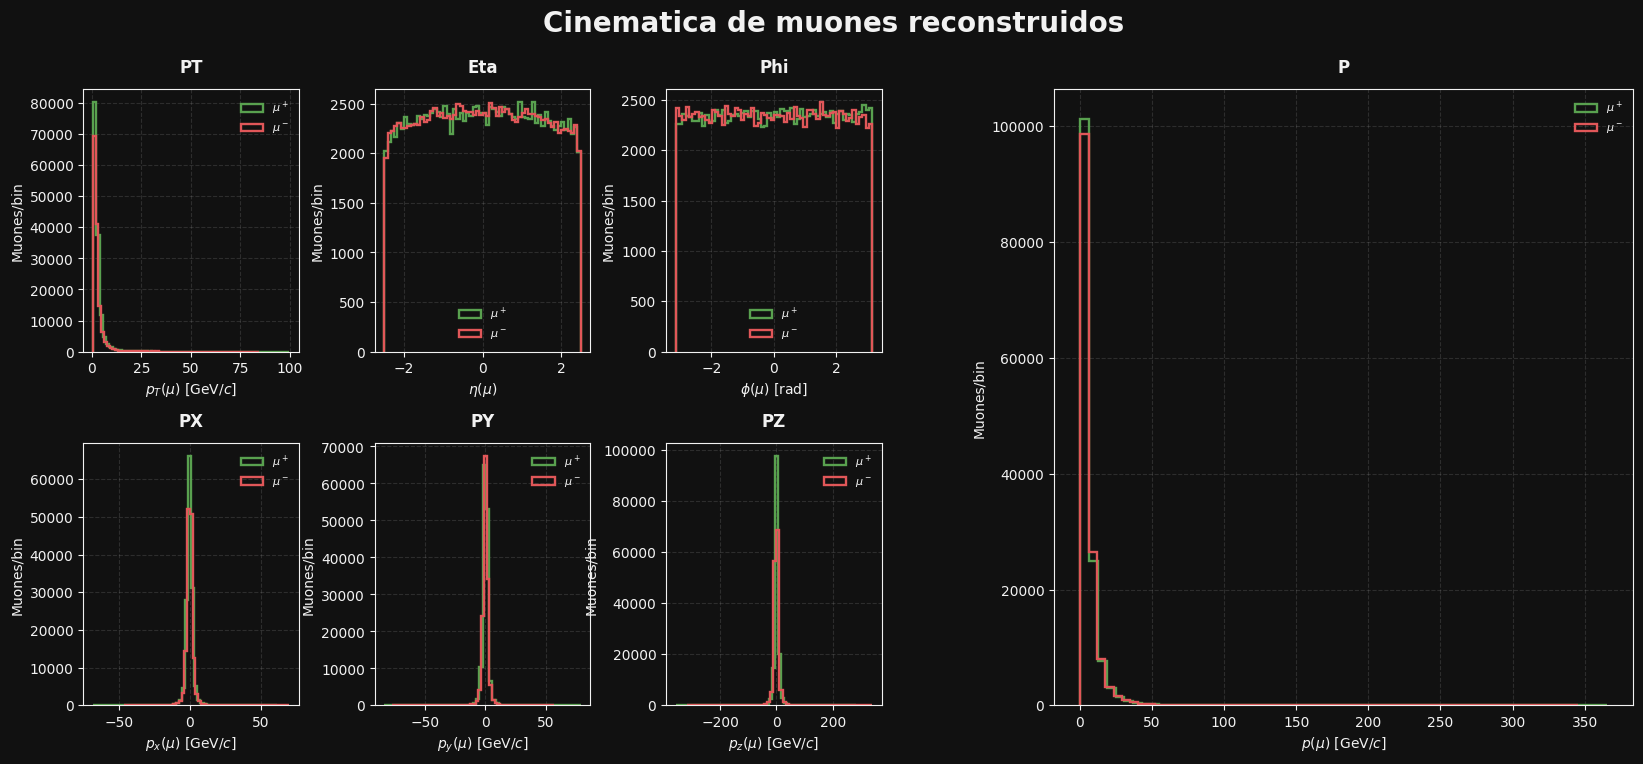

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [13]:
pt.plot_muon_kinematics(
    df_muons, 
    bins=60, 
    split_charge=True, 
    data='delphes02', 
    save=True, 
    filename="muon_kinematics_70GeV_02"
)

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\muon_kinematics_70GeV_02_cut.png.


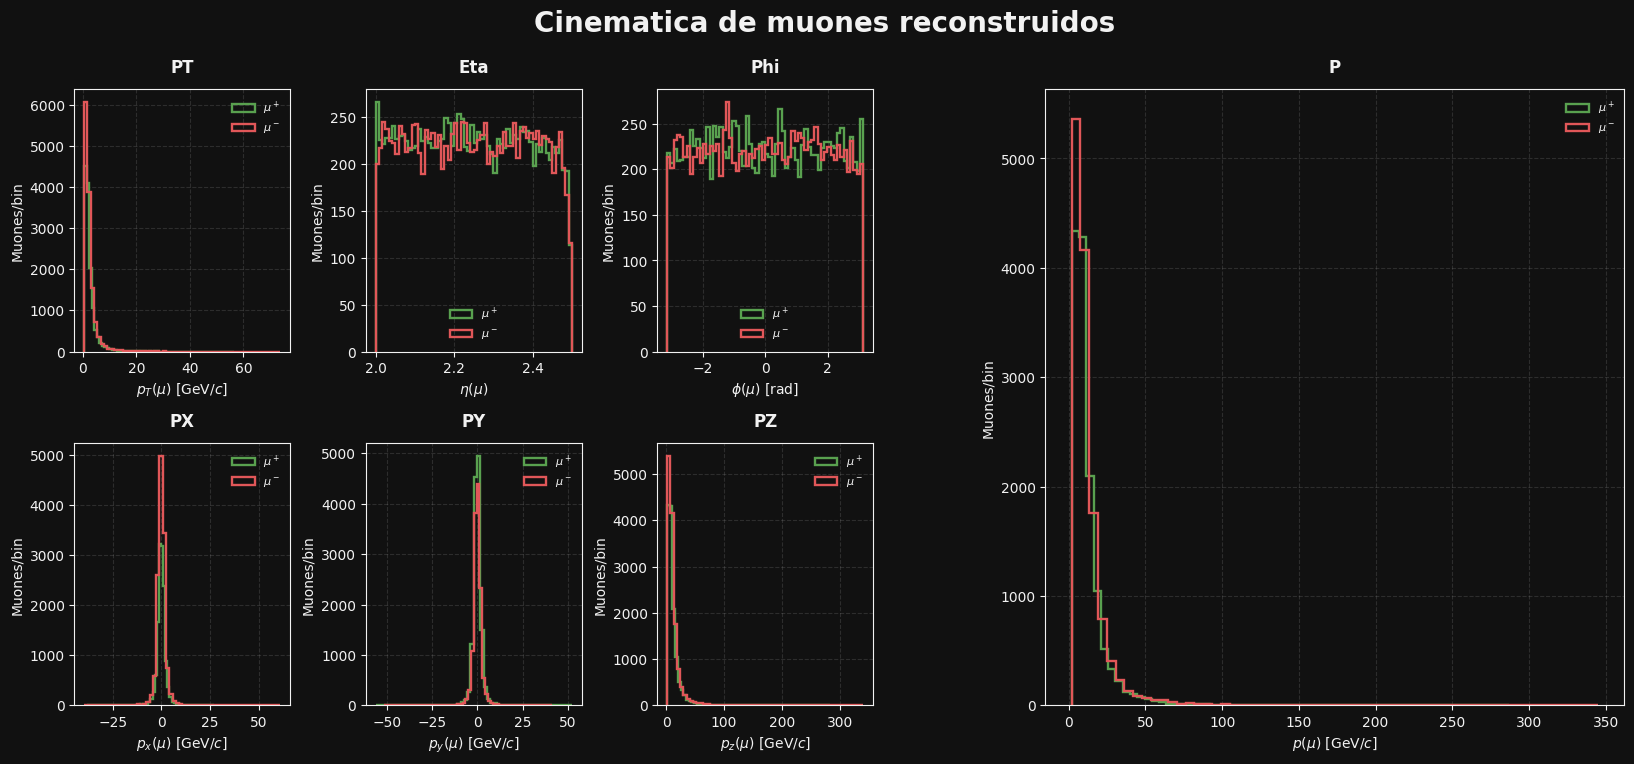

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [14]:
pt.plot_muon_kinematics(
    cdf_muons, 
    bins=60, 
    split_charge=True, 
    data='delphes02', 
    save=True, 
    filename="muon_kinematics_70GeV_02_cut"
)

In [28]:
df_muons = ph.calc_four_momentum(df_muons)
df_muons.head()

,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,SumPt,D0,DZ,ErrorD0,ErrorDZ,PX,PY,PZ,P,E
0,0,0,0,0,393,1.444203,1.588587,0.281821,1.088227e-08,-1,...,0.0,0.000000e+00,0.000000e+00,0.0,0.0,1.387230,0.401640,3.388541,3.683467,3.684982
1,0,0,0,1,392,1.141225,1.972527,-2.909900,1.040506e-08,1,...,0.0,0.000000e+00,0.000000e+00,0.0,0.0,-1.110730,-0.262054,4.022653,4.181403,4.182737
2,0,1,1,0,264,1.769708,2.136832,2.859703,1.029060e-08,-1,...,0.0,0.000000e+00,0.000000e+00,0.0,0.0,-1.699861,0.492282,7.392537,7.601412,7.602146
3,0,2,2,0,144,1.601895,-2.314334,0.630401,1.020527e-08,-1,...,0.0,6.544414e-14,-7.470573e-13,0.0,0.0,1.293997,0.944267,-8.024975,8.183293,8.183975
4,0,2,2,1,143,1.148552,-0.938239,-2.121283,6.948178e-09,1,...,0.0,0.000000e+00,0.000000e+00,0.0,0.0,-0.600810,-0.978877,-1.242826,1.692273,1.695568


In [29]:
cdf_muons = ph.calc_four_momentum(cdf_muons)
cdf_muons.head()

,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,SumPt,D0,DZ,ErrorD0,ErrorDZ,PX,PY,PZ,P,E
2,0,1,1,0,264,1.769708,2.136832,2.859703,1.029060e-08,-1,...,0.0,0.0,0.0,0.0,0.0,-1.699861,0.492282,7.392537,7.601412,7.602146
48,0,45,45,0,183,1.171718,2.065295,0.226416,1.033631e-08,1,...,0.0,0.0,0.0,0.0,0.0,1.141813,0.263035,4.546760,4.695311,4.696500
67,0,61,61,0,248,1.195463,2.144423,0.385404,1.028757e-08,1,...,0.0,0.0,0.0,0.0,0.0,1.107772,0.449415,5.032889,5.172920,5.173999
78,0,73,73,0,157,2.901314,2.194488,2.786878,1.025881e-08,-1,...,0.0,0.0,0.0,0.0,0.0,-2.720695,1.007694,12.858607,13.181859,13.182282
82,0,78,78,0,173,2.909660,2.041533,1.327660,1.035050e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.700494,2.824080,11.016809,11.394569,11.395059


In [17]:
df_tracks = io.load_dataframe(
    dataset=PDATASET01,
    tree_path="Tracks"
)
df_tracks.head()

Archivo: mpmm_70GeV_pandas.root
Árbol seleccionado: Tracks
Total de eventos: 2,443,494 eventos


,source_file_id,event_id,source_entry,object_index,root_uid,PID,Charge,IsPU,IsRecoPU,HardEnergyFraction,...,ErrorD0DZ,ErrorD0CtgTheta,ErrorPhiC,ErrorPhiDZ,ErrorPhiCtgTheta,ErrorCDZ,ErrorCCtgTheta,ErrorDZCtgTheta,Particle_ref,VertexIndex
0,0,0,0,0,389,211,1,0,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,140,-1
1,0,0,0,1,390,-211,-1,0,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,141,-1
2,0,0,0,2,391,211,1,0,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,281,-1
3,0,0,0,3,392,-13,1,0,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,79,-1
4,0,0,0,4,393,13,-1,0,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,80,-1


In [30]:
df_dimuons = ph.prepare_dimuon_analysis(df_muons, events=df_events)
df_dimuons.head(7)

,event_id,muplus_index,muplus_root_uid,muplus_pt,muplus_eta,muplus_phi,muplus_t,muplus_charge,muplus_particle_ref,muplus_isolation,...,dimuon_rapidity,cos_theta_star,muplus_d0_significance,muminus_d0_significance,muplus_chi2_ip_proxy,muminus_chi2_ip_proxy,sqrt_min_chi2_ip_proxy,min_chi2_ip_proxy,ip_proxy_valid,displacement_category
0,0,1,392,1.141225,1.972527,-2.909900,1.040506e-08,1,79,0.0,...,1.755291,-0.189646,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
1,2,1,143,1.148552,-0.938239,-2.121283,6.948178e-09,1,15,0.0,...,-1.721804,-0.596726,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
2,4,1,316,1.864763,-0.999608,0.324908,6.830922e-09,1,40,0.0,...,-1.431535,-0.346711,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
3,11,1,216,0.830079,-0.398254,2.855062,5.795263e-09,1,36,0.0,...,0.552510,0.568433,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
4,12,1,508,1.071112,-0.073025,2.336287,4.780955e-09,1,93,0.0,...,-0.908601,-0.443618,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
5,17,0,183,3.459536,-1.185972,-1.159755,7.760188e-09,1,42,0.0,...,-0.986191,0.280790,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
6,18,1,355,0.745108,1.566643,-0.968292,1.093666e-08,1,44,0.0,...,1.656096,0.055445,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid


In [31]:
cdf_dimuons = ph.prepare_dimuon_analysis(cdf_muons, events=df_events)
cdf_dimuons.head(7)

,event_id,muplus_index,muplus_root_uid,muplus_pt,muplus_eta,muplus_phi,muplus_t,muplus_charge,muplus_particle_ref,muplus_isolation,...,dimuon_rapidity,cos_theta_star,muplus_d0_significance,muminus_d0_significance,muplus_chi2_ip_proxy,muminus_chi2_ip_proxy,sqrt_min_chi2_ip_proxy,min_chi2_ip_proxy,ip_proxy_valid,displacement_category
0,129,0,177,2.460208,2.160101,0.951638,1.027712e-08,1,15,0.0,...,2.154195,-0.005146,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
1,773,0,172,3.729106,2.050864,-0.548498,1.034389e-08,1,23,0.0,...,2.168234,0.152056,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
2,1382,1,112,0.934022,2.244327,-0.820332,1.023707e-08,1,15,0.0,...,2.094963,-0.115223,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
3,1495,1,775,2.837064,2.145798,-1.233737,1.028495e-08,1,179,0.0,...,2.336941,0.135478,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
4,1607,1,1307,6.321775,2.096923,-0.159270,1.031360e-08,1,285,0.0,...,2.103765,0.006848,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
5,1702,1,455,0.950458,2.220622,2.432603,1.024843e-08,1,102,0.0,...,2.111393,-0.062579,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
6,1844,1,173,1.151559,2.324838,-2.735851,1.020166e-08,1,15,0.0,...,2.147786,-0.121603,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\dimuon_mass_70GeV_01.png.


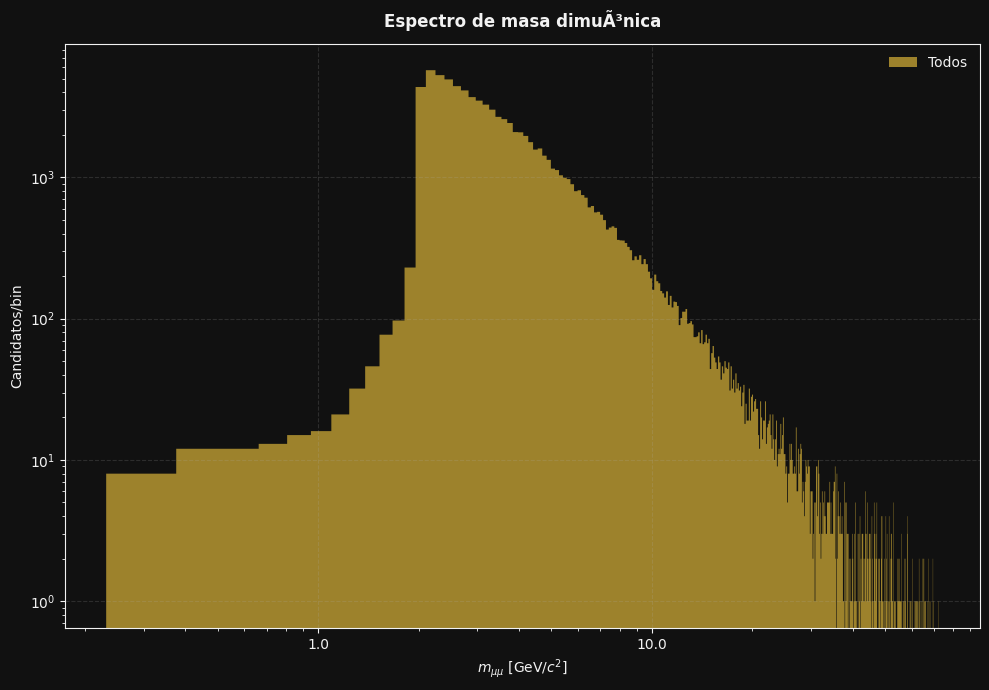

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Espectro de masa dimuÃ³nica'}, xlabel='$m_{\\mu\\mu}$ [GeV/$c^2$]', ylabel='Candidatos/bin'>)

In [47]:
pt.plot_dimuon_mass(
    df_dimuons,
    bins=500, 
    # mass_range=(0.0, 25.0), 
    save=True, 
    log_x=True,
    log_y=True, 
    data='delphes02', 
    filename="dimuon_mass_70GeV_01"
)

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\dimuon_mass_70GeV_01_cut.png.


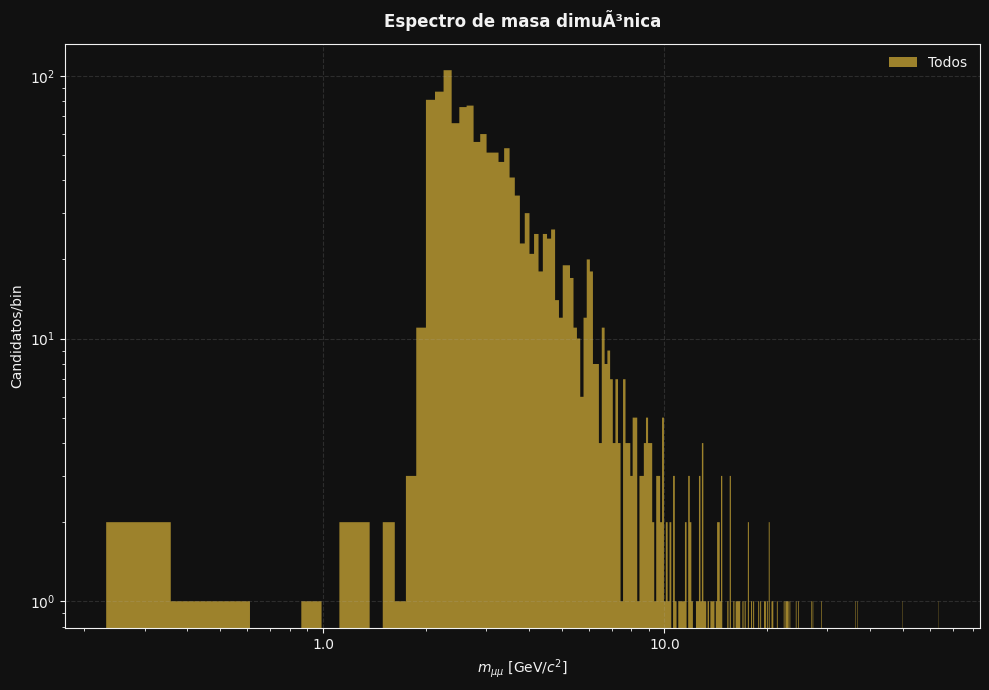

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Espectro de masa dimuÃ³nica'}, xlabel='$m_{\\mu\\mu}$ [GeV/$c^2$]', ylabel='Candidatos/bin'>)

In [52]:
pt.plot_dimuon_mass(
    cdf_dimuons, 
    bins=500, 
    # mass_range=(0.0, 50.0), 
    save=True, 
    log_x=True,
    log_y=True, 
    data='delphes02', 
    filename="dimuon_mass_70GeV_01_cut"
)

In [32]:
df_dimuons = ph.add_ip_proxies(df_dimuons, require_valid=False)
df_dimuons.head()

,event_id,muplus_index,muplus_root_uid,muplus_pt,muplus_eta,muplus_phi,muplus_t,muplus_charge,muplus_particle_ref,muplus_isolation,...,dimuon_rapidity,cos_theta_star,muplus_d0_significance,muminus_d0_significance,muplus_chi2_ip_proxy,muminus_chi2_ip_proxy,sqrt_min_chi2_ip_proxy,min_chi2_ip_proxy,ip_proxy_valid,displacement_category
0,0,1,392,1.141225,1.972527,-2.909900,1.040506e-08,1,79,0.0,...,1.755291,-0.189646,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
1,2,1,143,1.148552,-0.938239,-2.121283,6.948178e-09,1,15,0.0,...,-1.721804,-0.596726,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
2,4,1,316,1.864763,-0.999608,0.324908,6.830922e-09,1,40,0.0,...,-1.431535,-0.346711,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
3,11,1,216,0.830079,-0.398254,2.855062,5.795263e-09,1,36,0.0,...,0.552510,0.568433,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
4,12,1,508,1.071112,-0.073025,2.336287,4.780955e-09,1,93,0.0,...,-0.908601,-0.443618,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid


In [22]:
df_dimuons = ph.attach_dimuon_track_vertices(df_dimuons, df_tracks)
df_dimuons.head()

,event_id,muplus_index,muplus_root_uid,muplus_pt,muplus_eta,muplus_phi,muplus_t,muplus_charge,muplus_particle_ref,muplus_isolation,...,muminus_track_x_first_hit,muminus_track_y_first_hit,muminus_track_z_first_hit,muminus_track_d0,muminus_track_dz,muminus_track_error_d0,muminus_track_error_dz,muminus_track_error_d0_dz,muminus_track_matched,dimuon_tracks_matched
0,0,1,392,1.141225,1.972527,-2.909900,1.040506e-08,1,79,0.0,...,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,True,True
1,2,1,143,1.148552,-0.938239,-2.121283,6.948178e-09,1,15,0.0,...,0.0,0.0,0.0,6.544414e-14,-7.470573e-13,0.0,0.0,0.0,True,True
2,4,1,316,1.864763,-0.999608,0.324908,6.830922e-09,1,40,0.0,...,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,True,True
3,11,1,216,0.830079,-0.398254,2.855062,5.795263e-09,1,36,0.0,...,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,True,True
4,12,1,508,1.071112,-0.073025,2.336287,4.780955e-09,1,93,0.0,...,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,True,True


In [23]:
pt.plot_chi2_df_proxy(
    df_dimuons,
    category_column='displacement_category',
    data='delphes02'
)

TypeError: plot_chi2_df_proxy() got an unexpected keyword argument 'category_column'